<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_352_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1
Twin rotor system ynamic moedl
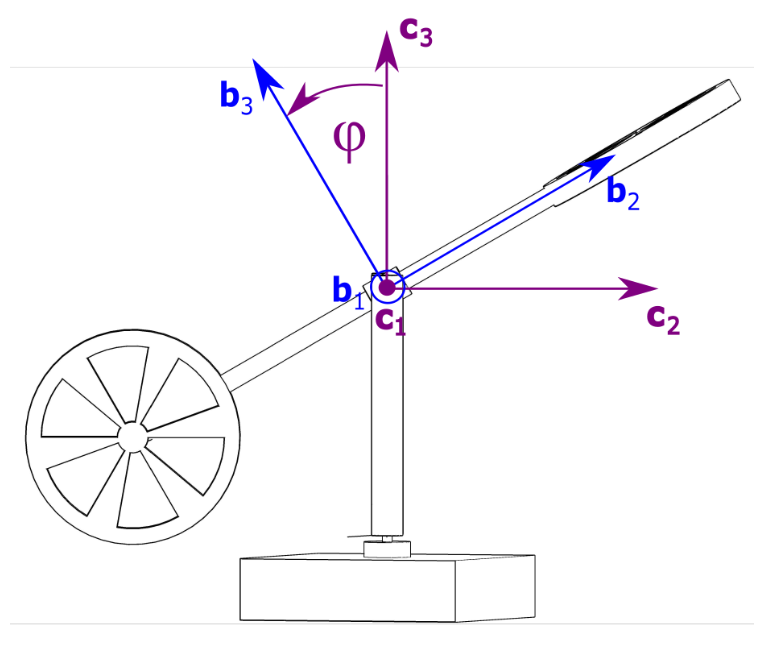

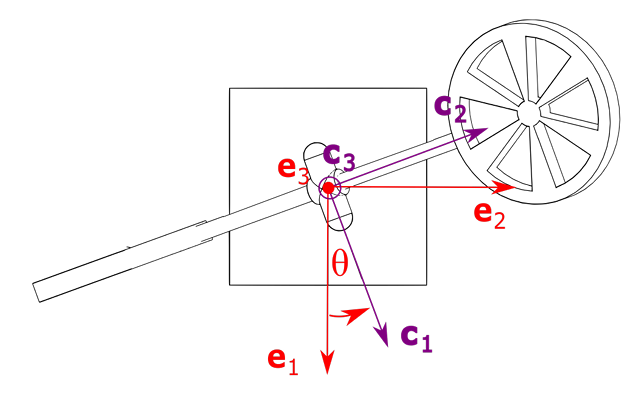


Show that the twin rotor system shown above can be modelled by

$$ \dot{R} = \widehat{\omega}R, $$
$$ \dot{\pi} = \tau^e + \tau^u, $$

where

$$ \omega = (\mathbb{I}^R)^{-1}\pi, $$

Here we have split the force and control moments into unmanipulatable and manipulatable (control) part. The manipulatable (control) part will be denoted by a superscript $u$ and takes the form

$$ \tau^u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos \alpha & -\cos \beta \\ \sin \alpha & -\sin \beta \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix} $$

and the constraint moment that prevents the rotation of the device about $\mathbb{b}_2$ axis is

$$ \tau^e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix} $$

with $T_2$ given by

$$ T_2 = e_2^T (\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega})$$

where $\Omega = R^T \omega$.

In [1]:
import numpy as np
import sympy as sp
from sympy import Matrix, symbols, sin, cos
from sympy.physics.mechanics import dynamicsymbols, init_vprinting

import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display, Math, Latex

# Install helper package
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"

import sims
mr = sims.RigidBodySim()

# Initialize pretty printing
init_vprinting()

# Define dynamic symbols
alpha, theta, phi, gamma, R, Omega, I = dynamicsymbols("alpha theta phi gamma R Omega I")

# Define ordinary symbols
t, I_1, I_2, I_3, l = symbols('t I_1 I_2 I_3 l')

# First and second derivatives
dtheta = sp.diff(theta, t)
ddtheta = sp.diff(dtheta, t)

dalpha = sp.diff(alpha, t)
ddalpha = sp.diff(dalpha, t)

dgamma = sp.diff(gamma, t)
ddgamma = sp.diff(dgamma, t)

dphi = sp.diff(phi, t)
ddphi = sp.diff(dphi, t)

# Rotation matrices
R1_phi = Matrix([
    [1, 0, 0],
    [0, cos(phi), -sin(phi)],
    [0, sin(phi),  cos(phi)]
])

R3_alpha = Matrix([
    [cos(alpha), -sin(alpha), 0],
    [sin(alpha),  cos(alpha), 0],
    [0, 0, 1]
])

R1_gamma = Matrix([
    [1, 0, 0],
    [0, cos(gamma), -sin(gamma)],
    [0, sin(gamma),  cos(gamma)]
])

R3_theta = Matrix([
    [cos(theta), -sin(theta), 0],
    [sin(theta),  cos(theta), 0],
    [0, 0, 1]
])

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#Activity 1
Configuration

### Kinematics and Angular Momentum Derivation

**1. Coordinate Frame Transformations**

The transformation from the inertial frame $\mathbf{e}$ to the intermediate frame $\mathbf{c}$ via a rotation $\theta$ about the $e_3$ axis:
$$\mathbf{c} = \mathbf{e} R_3(\theta), \quad R_3(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

The transformation from frame $\mathbf{c}$ to frame $\mathbf{b}$ via a rotation $\phi$ about the $c_1$ axis:
$$\mathbf{b} = \mathbf{c} R_1(\phi), \quad R_1(\phi) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

**2. Composite Rotation Matrix**

The total rotation from $\mathbf{e}$ to $\mathbf{b}$ is given by:
$$R = R_3(\theta) R_1(\phi)$$

**3. Angular Velocity Derivation**

The time derivative of the rotation matrix relates to the angular velocity tensor $\hat{\Omega}$:
$$\dot{R} = R \hat{\Omega}$$

Expanding the derivative:
$$\dot{R} = \dot{R}_3 R_1 + R_3 \dot{R}_1 = (R_3 \hat{\Omega}_3) R_1 + R_3 (R_1 \hat{\Omega}_1)$$

Solving for $\hat{\Omega}$ in the body frame:
$$\hat{\Omega} = R^T \dot{R} = R_1^T \hat{\Omega}_3 R_1 + \hat{\Omega}_1$$

The angular velocity vector $\Omega$ expressed in the body-fixed frame $\mathbf{b}$ is:
$$\Omega = \dot{\theta} R_1^T(\phi) \mathbf{e}_3 + \dot{\phi} \mathbf{e}_1$$

Evaluating the components:
$$\Omega = \begin{bmatrix} \dot{\phi} \\ \dot{\theta} \sin\phi \\ \dot{\theta} \cos\phi \end{bmatrix}$$

**4. Angular Momentum**

The angular momentum $\pi$ in the inertial frame $\mathbf{e}$ is:
$$\pi = R I \Omega$$

### 5. Constraint Moments
The constraint moment acting on the system prevents a rotation about the $\mathbf{b}_2$ axis.
The torque expressed in the inertial frame $\mathbf{e}$ is given by:

$$\mathbf{\tau}_e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}$$

Where $T_2$ represents the magnitude of the reaction torque maintaining the constraint against rotation in the second principal axis of the body frame.

### Actuation Torque Control Mapping
The actuation torque $\tau_u$ in the inertial frame is given by:

$$\tau_u = R T_u =R \begin{bmatrix} u_1 \cos\alpha - u_2 \cos\beta \\ 0 \\ u_1 \sin\alpha - u_2 \sin\beta \end{bmatrix}$$

In matrix form, this is expressed as:

$$\tau_u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos\alpha & -\cos\beta \\ \sin\alpha & -\sin\beta \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$$

## Equations of Motion

The rotational kinematics and dynamics in the inertial frame are given by:

$$\dot{R} = \widehat{\omega} R$$
$$\pi = R \mathbb{I} R^T \omega$$
$$\dot{\pi} = R T_u = \tau_u + \tau_e$$

### Constraint Moment Derivation
The constraint moment $T_2$ is found by projecting the body-frame torque onto the second principal axis:

$$T_2 = e_2^T R^T \dot{\pi}$$
$$T_2 = e_2^T \left( \Omega \times \mathbb{I} \Omega + \mathbb{I} \dot{\Omega} \right)$$

# Activity 2

# Rigid Body Dynamics in Body Frame

The dynamics are governed by Euler’s rigid body equation in the body frame $b$:

$$\mathbf{T}_u + \mathbf{T}_e = I\dot{\Omega} + \Omega \times (I\Omega)$$



### 1. Angular Velocity in Body Frame
$$\Omega = \begin{bmatrix} \dot{\phi} \\ \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi \end{bmatrix}$$

### 2. Angular Acceleration in Body Frame
$$\dot{\Omega} = \begin{bmatrix} \ddot{\phi} \\ \ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi \\ \ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi \end{bmatrix}$$

### 3. Moment of Inertia Matrix
$$I = \text{diag}(I_1, I_2, I_3)$$


### 4. Gyroscopic Effect Term
$$\Omega \times (I\Omega) = \begin{bmatrix} \dot{\phi} \\ \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi \end{bmatrix} \times \begin{bmatrix} I_1\dot{\phi} \\ I_2\dot{\theta}\sin\phi \\ I_3\dot{\theta}\cos\phi \end{bmatrix}$$

**Expanded Form:**
$$\Omega \times (I\Omega) = \begin{bmatrix} (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi \\ (I_1 - I_3)\dot{\theta}\dot{\phi}\cos\phi \\ (I_2 - I_1)\dot{\theta}\dot{\phi}\sin\phi \end{bmatrix}$$


### 5. Applied Torques
**Thrust Torque:**
$$\mathbf{T}_u = \begin{bmatrix} u_1\cos\alpha - u_2\cos\beta \\ 0 \\ u_1\sin\alpha - u_2\sin\beta \end{bmatrix}$$

**External Reaction Torque:**
$$\mathbf{T}_e = \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}$$



### 6. Substituting into Euler Equation
$$\begin{bmatrix} u_1\cos\alpha - u_2\cos\beta \\ T_2 \\ u_1\sin\alpha - u_2\sin\beta \end{bmatrix} = \begin{bmatrix} I_1\ddot{\phi} \\ I_2(\ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi) \\ I_3(\ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi) \end{bmatrix} + \begin{bmatrix} (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi \\ (I_1 - I_3)\dot{\theta}\dot{\phi}\cos\phi \\ (I_2 - I_1)\dot{\theta}\dot{\phi}\sin\phi \end{bmatrix}$$





# State-Space Representation

### State Vector
The system state is defined by the vector $x$, containing the angular positions and velocities:

$$x = \begin{bmatrix} \theta \\ \phi \\ \dot{\theta} \\ \dot{\phi} \end{bmatrix}$$



### State Equations
The derivative of the state vector is given by:

$$\dot{x} = \begin{bmatrix} \dot{\theta} \\ \dot{\phi} \\ \ddot{\theta} \\ \ddot{\phi} \end{bmatrix}$$



### 1. Roll Acceleration ($\ddot{\phi}$)
Derived from the roll torque balance:

$$\ddot{\phi} = \frac{1}{I_1} \left[ (u_1\cos\alpha - u_2\cos\beta) - (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi \right]$$

### 2. Pitch Acceleration ($\ddot{\theta}$) — Corrected
Solving for $\ddot{\theta}$ while accounting for the coupling effects and the geometric constraints:

$$\ddot{\theta} = \frac{1}{I_3 \cos\phi} \left[ (u_1\sin\alpha - u_2\sin\beta) - (I_2 - I_1)\dot{\theta}\dot{\phi}\sin\phi \right] + \dot{\theta}\dot{\phi}\tan\phi$$

# Final State-Space Model

The complete nonlinear state-space representation of the modified rigid body system is given by the vector field $\dot{x} = f(x, u)$:



$$\dot{x} = \begin{bmatrix}
\dot{\theta} \\
\dot{\phi} \\
\frac{1}{I_3 \cos\phi} \left[ (u_1\sin\alpha - u_2\sin\beta) - (I_2 - I_1)\dot{\theta}\dot{\phi}\sin\phi \right] + \dot{\theta}\dot{\phi}\tan\phi \\
\frac{1}{I_1} \left[ (u_1\cos\alpha - u_2\cos\beta) - (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi \right]
\end{bmatrix}$$

---

### Model Breakdown

| State Variable | Description |
| :--- | :--- |
| $\theta$ | Pitch angle |
| $\phi$ | Roll angle |
| $\dot{\theta}$ | Pitch rate |
| $\dot{\phi}$ | Roll rate |

### Parameter Definitions
* **Inertia:** $I_1, I_2, I_3$ are the principal moments of inertia.
* **Inputs:** $u_1, u_2$ are thrust magnitudes; $\alpha, \beta$ are thrust vectoring angles.
* **Geometric Terms:** The $\tan\phi$ and $\sec\phi$ (implied by $1/\cos\phi$) terms represent the kinematic coupling between the axes.



# Activity 3

# Trajectory Tracking Error on $SO(3)$

The objective of the controller is to ensure the rigid body tracks a desired reference trajectory by minimizing the distance between the actual and desired rotation matrices.

### 1. Reference Quantities
We define the following time-varying reference parameters:

* $R_r(t) \in SO(3)$: Desired rotation matrix (reference trajectory)
* $\omega_r(t)$: Desired angular velocity
* $\pi_r(t)$: Desired angular momentum

The actual orientation is represented by $R(t) \in SO(3)$.


### 2. Rotation Matrices
Both $R$ and $R_r$ are elements of the **Special Orthogonal Group**, defined as:
$$SO(3) = \{ R \in \mathbb{R}^{3 \times 3} \mid R^T R = I, \det(R) = 1 \}$$



#### Error in Body Frame
$$R_e = R^T R_r$$.

####Error in Reference Frame
$$R_e = R_r^T R$$

#### (c) Error in Spatial (Inertial) Frame
$$R_e = R_r R^T \quad \text{or} \quad R_e = R R_r^T$$

.

# Geometric Tracking Control on $SO(3)$ (Clean Derivation)

### 1. Objective
The goal is to design a controller such that the rigid body tracks a desired trajectory:
* $R_r(t) \in SO(3)$: Desired orientation
* $\omega_r(t)$: Desired angular velocity
* $\pi_r(t)$: Desired angular momentum

### 2. Spatial Frame Error Definition
We use spatial frame error:
$$R_e = R_r R^T$$

### 3. Angular Velocity Error
Define the skew-symmetric (hat) operator:
$$\hat{\omega}_e = \dot{R}_e R_e^T$$

Then,
$$\hat{\omega}_e = \hat{\omega}_r - R_e \hat{\omega} R_e^T$$

Thus, the vector form:
$$\omega_e = \omega_r - R_e \omega$$

### 4. Angular Momentum Error
$$\pi_e = R I R^T \omega_e$$

Substitute $\omega_e$:
$$\pi_e = R I R^T (\omega_r - R_e \omega)$$

Using $\pi = R I R^T \omega$, we obtain:
$$\pi_e = R_e^T \pi_r - \pi$$

### 5. Error Dynamics
Differentiate:
$$\dot{\pi}_e = R_e^T(\dot{\pi}_r - \omega_e \times \pi_r) - \dot{\pi}$$

### 6. Reference Representation
Let $\pi_r = R_r \Pi_r$. Then:
$$\dot{\pi}_r = \dot{R}_r \Pi_r + R_r \dot{\Pi}_r$$

Substitute into error dynamics:
$$\dot{\pi}_e = R_e^T \left( R_r \dot{\Pi}_r + (\omega_r - \omega_e) \times \pi_r \right) - \dot{\pi}$$

Simplifying:
$$\dot{\pi}_e = \left( R \dot{\Pi}_r + \omega \times R_e^T \pi_r \right) - \dot{\pi}$$

### 7. Final Error Dynamics
$$\dot{R}_e = \hat{\omega}_e R_e$$
$$\dot{\pi}_e = \left( R \dot{\Pi}_r + \omega \times R_e^T \pi_r \right) - \tau_u - \tau_e$$


### 8. Lyapunov Function (Virtual Potential Energy)
$$V(R_e) = \frac{1}{2} \text{tr}\left( K (I - R_e) \right)$$
where $K = \text{diag}(K_1, K_2, K_3)$.

### 9. Configuration Error
$$\hat{e}_R = \frac{1}{2}(R_e K - K R_e^T)$$
$$e_R = (\hat{e}_R)^\vee$$

### 10. Integral Error
$$\dot{e}_{IR} = e_R$$

### 11. Desired Error Dynamics (PID Form)
$$\dot{\pi}_e = - k_P e_R - k_D \pi_e - k_I e_{IR}$$

### 12. Control Law (Spatial Frame)
Equating dynamics:
$$- k_P e_R - k_D \pi_e - k_I e_{IR} = (R \dot{\Pi}_r + \omega \times R_e^T \pi_r) - \tau_u - \tau_e$$

Thus,
$$\tau_u = - \tau_e + (R \dot{\Pi}_r + \omega \times R_e^T \pi_r) + k_P e_R + k_D \pi_e + k_I e_{IR}$$


### 13. Body Frame Formulation

**Rotation Error:**
$$R_e = R^T R_r$$

**Angular Velocity Error:**
$$\Omega_e = \Omega - R_e \Omega_r$$

**Angular Momentum Error:**
$$\Pi_e = I \Omega_e = I(\Omega - R_e \Omega_r)$$

**Error Dynamics:**
$$\dot{\Pi}_e = I\dot{\Omega}_e = I\left(\dot{\Omega} - \dot{R}_e \Omega_r - R_e \dot{\Omega}_r \right)$$

Using $\dot{R}_e = -\hat{\Omega} R_e + R_e \hat{\Omega}_r$ and $\dot{R}_e \Omega_r = -\Omega \times (R_e \Omega_r)$:
$$\dot{\Pi}_e = I\dot{\Omega} + I(\Omega \times R_e \Omega_r) - I R_e \dot{\Omega}_r$$

**Using Euler Equation ($I\dot{\Omega} = \tau_u + \tau_e - \Omega \times I\Omega$):**
$$\dot{\Pi}_e = I(\Omega \times R_e \Omega_r - R_e \dot{\Omega}_r) - \Omega \times I\Omega + \tau_u + \tau_e$$

### 14. Lyapunov-Based PID Control
$$V(R_e) = \frac{1}{2}\text{tr}(K(I - R_e))$$
$$\hat{e}_R = \frac{1}{2}(R_e^T K - K R_e)$$
$$e_R = (\hat{e}_R)^\vee, \quad \dot{e}_{IR} = e_R$$

**Desired PID Dynamics:**
$$\dot{\Pi}_e = - k_P e_R - k_D \Pi_e - k_I e_{IR}$$


### 15. Final Control Law (Body Frame)
$$\tau_u = - \tau_e + \Omega \times I\Omega - I(\Omega \times R_e \Omega_r - R_e \dot{\Omega}_r) + k_P e_R + k_D \Pi_e + k_I e_{IR}$$


### Control Structure Interpretation

**Feedforward (Model-Based Compensation):**
* $-\tau_e \to$ Disturbance rejection
* $\Omega \times I\Omega \to$ Gyroscopic cancellation
* $-I(\Omega \times R_e \Omega_r - R_e \dot{\Omega}_r) \to$ Reference tracking

**Feedback (PID Stabilization):**
* $k_P e_R \to$ Orientation correction (virtual spring)
* $k_D \Pi_e \to$ Damping (reduces oscillation)
* $k_I e_{IR} \to$ Eliminates steady-state error